# 01 - Synthetic Stock Data and Correlation Setup

This notebook creates the synthetic market inputs used in the project.

It focuses on:

- asset-level Black-Scholes parameters,
- constant, calm, and stress correlation matrices,
- simulated stock-price paths under constant correlation,
- simulated stock-price paths under regime-switching correlation,
- empirical correlation diagnostics from the generated data.

The baseline setup uses zero dividend yields for all assets so the first version stays focused on correlation model risk.

Pricing and hedging will be built in later notebooks.

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(42)
np.set_printoptions(precision=3, suppress=True)

In [18]:
asset_names = ["Asset 1", "Asset 2", "Asset 3"]
n_assets = len(asset_names)

spot = np.array([100.0, 95.0, 110.0])
weights = np.array([0.40, 0.35, 0.25])
vol = np.array([0.20, 0.25, 0.22])
div_yield = np.zeros(n_assets)

rate = 0.03
maturity = 1.0
steps = 252
dt = maturity / steps
n_paths = 3000

rho_constant = 0.35
rho_calm = 0.20
rho_stress = 0.75
p01 = 0.03
p10 = 0.12
start_regime = 0

parameter_table = pd.DataFrame(
    {
        "spot": spot,
        "weight": weights,
        "volatility": vol,
        "dividend_yield": div_yield,
    },
    index=asset_names,
)

market_settings = pd.Series(
    {
        "risk_free_rate": rate,
        "maturity_years": maturity,
        "time_steps": steps,
        "monte_carlo_paths": n_paths,
        "rho_constant": rho_constant,
        "rho_calm": rho_calm,
        "rho_stress": rho_stress,
        "p01": p01,
        "p10": p10,
    },
    name="value",
)

display(parameter_table)
display(market_settings.to_frame())

,spot,weight,volatility,dividend_yield
Asset 1,100.0,0.40,0.20,0.0
Asset 2,95.0,0.35,0.25,0.0
Asset 3,110.0,0.25,0.22,0.0


,value
risk_free_rate,0.03
maturity_years,1.00
time_steps,252.00
monte_carlo_paths,3000.00
rho_constant,0.35
rho_calm,0.20
rho_stress,0.75
p01,0.03
p10,0.12


## Helper Functions

The project uses an equicorrelation structure for a first clean synthetic setup. This keeps the correlation matrices valid and easy to interpret while we build the pricing pipeline.

In [19]:
def equicorrelation_matrix(n_assets, rho):
    lower_bound = -1.0 / (n_assets - 1)
    if not (lower_bound < rho < 1.0):
        raise ValueError(f"rho must lie in ({lower_bound:.3f}, 1.0) for a positive-definite equicorrelation matrix")

    corr = np.full((n_assets, n_assets), rho)
    np.fill_diagonal(corr, 1.0)
    return corr


def is_positive_definite(matrix, tolerance=1e-12):
    eigenvalues = np.linalg.eigvalsh(matrix)
    return np.all(eigenvalues > tolerance), eigenvalues


def simulate_constant_correlation_paths(spot, rate, div_yield, vol, corr, maturity, steps, n_paths, rng):
    n_assets = spot.size
    dt = maturity / steps
    drift = (rate - div_yield - 0.5 * vol ** 2) * dt
    diffusion = vol * np.sqrt(dt)
    chol = np.linalg.cholesky(corr)

    paths = np.empty((n_paths, steps + 1, n_assets))
    paths[:, 0, :] = spot

    for step in range(steps):
        shocks = rng.standard_normal((n_paths, n_assets)) @ chol.T
        log_increment = drift + diffusion * shocks
        paths[:, step + 1, :] = paths[:, step, :] * np.exp(log_increment)

    return paths


def simulate_regime_paths(n_paths, steps, p01, p10, start_regime, rng):
    regimes = np.empty((n_paths, steps), dtype=np.int8)
    regimes[:, 0] = start_regime

    for step in range(1, steps):
        previous = regimes[:, step - 1]
        draws = rng.random(n_paths)
        current = previous.copy()
        current[(previous == 0) & (draws < p01)] = 1
        current[(previous == 1) & (draws < p10)] = 0
        regimes[:, step] = current

    return regimes


def simulate_regime_switching_paths(
    spot,
    rate,
    div_yield,
    vol,
    corr_calm,
    corr_stress,
    maturity,
    steps,
    n_paths,
    p01,
    p10,
    start_regime,
    rng,
):
    n_assets = spot.size
    dt = maturity / steps
    drift = (rate - div_yield - 0.5 * vol ** 2) * dt
    diffusion = vol * np.sqrt(dt)

    regimes = simulate_regime_paths(n_paths, steps, p01, p10, start_regime, rng)
    chol_by_regime = {
        0: np.linalg.cholesky(corr_calm),
        1: np.linalg.cholesky(corr_stress),
    }

    paths = np.empty((n_paths, steps + 1, n_assets))
    paths[:, 0, :] = spot

    for step in range(steps):
        base_draws = rng.standard_normal((n_paths, n_assets))
        correlated_draws = np.empty_like(base_draws)

        for regime_value in (0, 1):
            mask = regimes[:, step] == regime_value
            if np.any(mask):
                correlated_draws[mask] = base_draws[mask] @ chol_by_regime[regime_value].T

        log_increment = drift + diffusion * correlated_draws
        paths[:, step + 1, :] = paths[:, step, :] * np.exp(log_increment)

    return paths, regimes


def flatten_log_returns(paths, asset_names):
    log_returns = np.log(paths[:, 1:, :] / paths[:, :-1, :]).reshape(-1, paths.shape[-1])
    return pd.DataFrame(log_returns, columns=asset_names)

In [20]:
corr_constant = equicorrelation_matrix(n_assets, rho_constant)
corr_calm = equicorrelation_matrix(n_assets, rho_calm)
corr_stress = equicorrelation_matrix(n_assets, rho_stress)

for label, matrix in [("Constant", corr_constant), ("Calm", corr_calm), ("Stress", corr_stress)]:
    positive_definite, eigenvalues = is_positive_definite(matrix)
    print(f"{label} correlation matrix positive definite: {positive_definite}; eigenvalues = {np.round(eigenvalues, 4)}")
    display(pd.DataFrame(matrix, index=asset_names, columns=asset_names))

Constant correlation matrix positive definite: True; eigenvalues = [0.65 0.65 1.7 ]


,Asset 1,Asset 2,Asset 3
Asset 1,1.00,0.35,0.35
Asset 2,0.35,1.00,0.35
Asset 3,0.35,0.35,1.00


Calm correlation matrix positive definite: True; eigenvalues = [0.8 0.8 1.4]


,Asset 1,Asset 2,Asset 3
Asset 1,1.0,0.2,0.2
Asset 2,0.2,1.0,0.2
Asset 3,0.2,0.2,1.0


Stress correlation matrix positive definite: True; eigenvalues = [0.25 0.25 2.5 ]


,Asset 1,Asset 2,Asset 3
Asset 1,1.00,0.75,0.75
Asset 2,0.75,1.00,0.75
Asset 3,0.75,0.75,1.00


## Generate Synthetic Paths

In [21]:
constant_paths = simulate_constant_correlation_paths(
    spot=spot,
    rate=rate,
    div_yield=div_yield,
    vol=vol,
    corr=corr_constant,
    maturity=maturity,
    steps=steps,
    n_paths=n_paths,
    rng=rng,
)

switching_paths, switching_regimes = simulate_regime_switching_paths(
    spot=spot,
    rate=rate,
    div_yield=div_yield,
    vol=vol,
    corr_calm=corr_calm,
    corr_stress=corr_stress,
    maturity=maturity,
    steps=steps,
    n_paths=n_paths,
    p01=p01,
    p10=p10,
    start_regime=start_regime,
    rng=rng,
)

constant_returns = flatten_log_returns(constant_paths, asset_names)
switching_returns = flatten_log_returns(switching_paths, asset_names)

constant_empirical_corr = constant_returns.corr()
switching_empirical_corr = switching_returns.corr()

summary_table = pd.DataFrame(
    {
        "spot": spot,
        "mean_terminal_constant": constant_paths[:, -1, :].mean(axis=0),
        "mean_terminal_switching": switching_paths[:, -1, :].mean(axis=0),
        "ann_vol_constant": constant_returns.std().values * np.sqrt(252),
        "ann_vol_switching": switching_returns.std().values * np.sqrt(252),
    },
    index=asset_names,
)

display(summary_table.round(3))
print(f"Average fraction of time spent in the stress regime: {switching_regimes.mean():.2%}")

,spot,mean_terminal_constant,mean_terminal_switching,ann_vol_constant,ann_vol_switching
Asset 1,100.0,102.909,103.669,0.20,0.20
Asset 2,95.0,98.413,97.942,0.25,0.25
Asset 3,110.0,113.711,114.455,0.22,0.22


Average fraction of time spent in the stress regime: 19.51%


/var/folders/6n/xbpdfg2s7z5_z4t3j_8fzz7r0000gn/T/ipykernel_95279/550204694.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


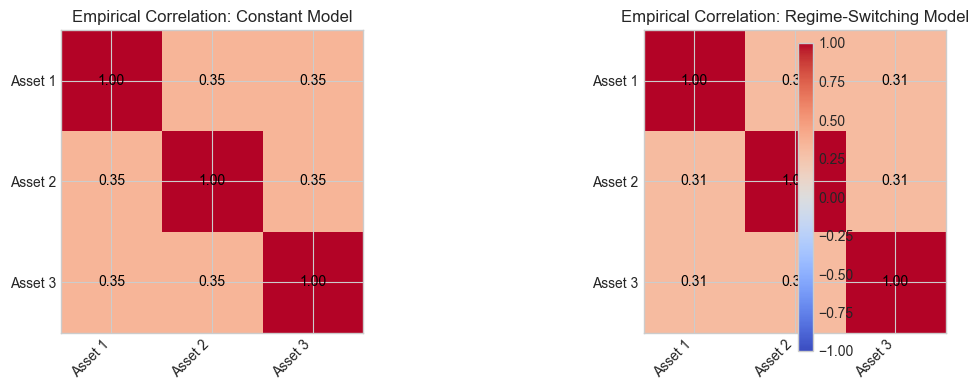

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, title, matrix in zip(
    axes,
    ["Empirical Correlation: Constant Model", "Empirical Correlation: Regime-Switching Model"],
    [constant_empirical_corr.values, switching_empirical_corr.values],
):
    image = ax.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(n_assets), asset_names, rotation=45, ha="right")
    ax.set_yticks(range(n_assets), asset_names)
    ax.set_title(title)

    for i in range(n_assets):
        for j in range(n_assets):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(image, ax=axes, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

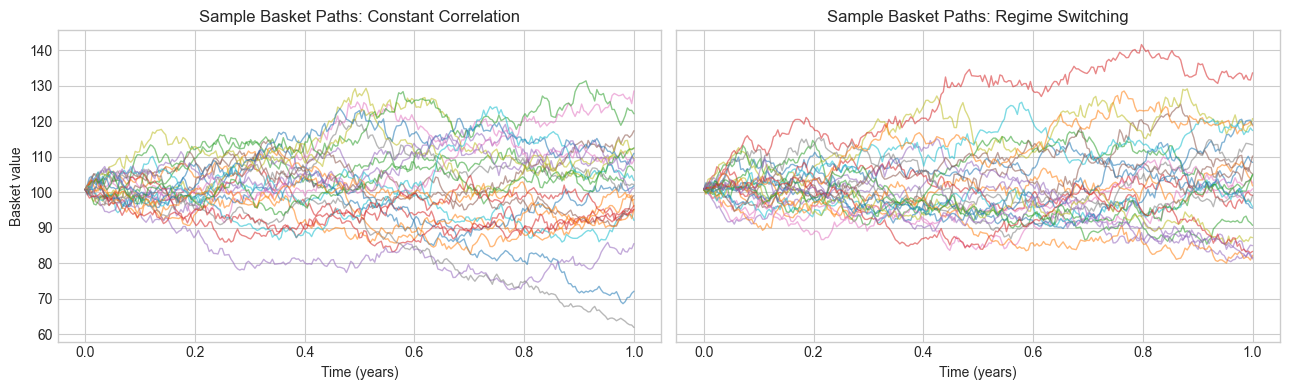

In [23]:
time_grid = np.linspace(0.0, maturity, steps + 1)
basket_constant = (constant_paths * weights).sum(axis=2)
basket_switching = (switching_paths * weights).sum(axis=2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for idx in range(25):
    axes[0].plot(time_grid, basket_constant[idx], alpha=0.55, lw=1)
    axes[1].plot(time_grid, basket_switching[idx], alpha=0.55, lw=1)

axes[0].set_title("Sample Basket Paths: Constant Correlation")
axes[1].set_title("Sample Basket Paths: Regime Switching")
axes[0].set_xlabel("Time (years)")
axes[1].set_xlabel("Time (years)")
axes[0].set_ylabel("Basket value")
plt.tight_layout()
plt.show()

## Persist Synthetic Data

The next notebooks can load these files directly instead of regenerating the same market inputs every time.

In [24]:
base_dir = Path.cwd()
repo_root = base_dir.parent if base_dir.name == "notebooks" else base_dir
output_dir = repo_root / "data" / "synthetic"
output_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    output_dir / "synthetic_market_data.npz",
    asset_names=np.array(asset_names, dtype="U"),
    spot=spot,
    weights=weights,
    vol=vol,
    div_yield=div_yield,
    rate=rate,
    maturity=maturity,
    steps=steps,
    n_paths=n_paths,
    p01=p01,
    p10=p10,
    start_regime=start_regime,
    constant_paths=constant_paths,
    switching_paths=switching_paths,
    switching_regimes=switching_regimes,
    corr_constant=corr_constant,
    corr_calm=corr_calm,
    corr_stress=corr_stress,
)

parameter_table.to_csv(output_dir / "asset_parameters.csv")
market_settings.to_csv(output_dir / "market_settings.csv")
constant_empirical_corr.to_csv(output_dir / "constant_empirical_correlation.csv")
switching_empirical_corr.to_csv(output_dir / "switching_empirical_correlation.csv")

print(f"Saved synthetic data bundle to {output_dir.resolve()}")

Saved synthetic data bundle to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic
